# Automated Quality Control with Transfer Learning
### Manufacturing Defect Detection — Discovery-to-Action (DTA) Strategy

**Author:** AI Vision Engineering Project
**Base architecture:** ResNet50 (ImageNet pre-trained)
**Task:** Binary image classification — `good` vs `defective` manufactured parts
**Framework:** TensorFlow / Keras

---

## Project Brief

This notebook adapts a pre-trained ResNet50 convolutional neural network to a factory
quality-control task using **transfer learning**. Rather than training a CNN from
scratch (which would require tens of thousands of labeled defect images and
days of GPU time), we reuse the visual feature extraction already learned by ResNet50
on ImageNet — edges, textures, shapes, gradients — and only train a small
classification head on top of it for our specific task: spotting defective parts.

The notebook follows the **Discovery-to-Action (DTA)** framework:

| Phase | What happens |
|---|---|
| **Discovery** | Prepare and understand the data: standardize images, augment the training set, split into train/test |
| **Technical ("Brain Swap")** | Strip the ImageNet classification head off ResNet50, freeze its feature-extraction backbone, and attach a new head trained for our binary task |
| **Action** | Convert raw probability outputs into a concrete automation decision a robotic arm can act on |

> **Note on the dataset:** This notebook uses a **synthetically generated** dataset of
> procedurally rendered "manufactured part" images (clean rings/discs vs. the same
> parts with scratches, dents, cracks, or stains overlaid). This guarantees the
> notebook runs end-to-end for any reviewer with zero external downloads or
> credentials. The exact same code works unmodified on a real dataset — see the
> **"Using a Real Dataset"** section near the end for the one-line swap.


## 0. Environment Setup

This notebook is designed to run in **Google Colab** with a GPU runtime
(`Runtime → Change runtime type → GPU`). It also runs on a local Jupyter
installation with `tensorflow>=2.10`.


In [1]:
# Core imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.20.0
GPU available: False


## 1. Discovery Phase — Dataset Preparation

### 1.1 Generating a Synthetic QC Image Dataset

We simulate a factory inspection camera by procedurally rendering two classes of images:

- **`good`** — a clean, circular machined part (e.g. a washer/ring) on a noisy gray
  conveyor-belt-style background, with natural machining texture lines.
- **`defective`** — the same base part with one or more of: a **scratch**, **dent**,
  **crack**, or **stain** overlaid.

This keeps the notebook fully self-contained and reproducible. Swap in real factory
images later with no code changes (see the end of this notebook).


In [2]:
def make_background(size=300, base_gray=160, noise_std=8, seed=None):
    rng = np.random.default_rng(seed)
    base = np.full((size, size), base_gray, dtype=np.float32)
    noise = rng.normal(0, noise_std, (size, size))
    img = np.clip(base + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(img, mode="L").convert("RGB")


def draw_good_part(size=300, seed=None):
    rng = random.Random(seed)
    img = make_background(size=size, seed=seed)
    draw = ImageDraw.Draw(img)

    cx, cy = size // 2 + rng.randint(-10, 10), size // 2 + rng.randint(-10, 10)
    r_outer = rng.randint(90, 110)
    r_inner = r_outer - rng.randint(25, 40)

    metal_shade = rng.randint(190, 215)
    draw.ellipse(
        [cx - r_outer, cy - r_outer, cx + r_outer, cy + r_outer],
        fill=(metal_shade, metal_shade, metal_shade + 5),
        outline=(metal_shade - 40, metal_shade - 40, metal_shade - 35),
        width=3,
    )
    bg_shade = rng.randint(150, 170)
    draw.ellipse(
        [cx - r_inner, cy - r_inner, cx + r_inner, cy + r_inner],
        fill=(bg_shade, bg_shade, bg_shade),
    )

    # subtle machined-ring texture lines (normal manufacturing texture, NOT a defect)
    for _ in range(4):
        rr = rng.randint(r_inner + 5, r_outer - 5)
        shade = metal_shade - rng.randint(5, 15)
        draw.ellipse([cx - rr, cy - rr, cx + rr, cy + rr],
                      outline=(shade, shade, shade), width=1)

    return img.filter(ImageFilter.GaussianBlur(radius=0.6))


def add_defect(img, defect_type, seed=None):
    rng = random.Random(seed)
    draw = ImageDraw.Draw(img)
    size = img.size[0]
    cx, cy = size // 2, size // 2

    if defect_type == "scratch":
        x1 = rng.randint(cx - 80, cx + 20)
        y1 = rng.randint(cy - 80, cy + 20)
        length = rng.randint(40, 90)
        angle = rng.uniform(0, np.pi)
        x2 = int(x1 + length * np.cos(angle))
        y2 = int(y1 + length * np.sin(angle))
        draw.line([x1, y1, x2, y2], fill=(40, 40, 40), width=rng.randint(2, 4))

    elif defect_type == "dent":
        dx, dy = cx + rng.randint(-60, 60), cy + rng.randint(-60, 60)
        r = rng.randint(8, 18)
        draw.ellipse([dx - r, dy - r, dx + r, dy + r], fill=(90, 90, 95))
        draw.ellipse([dx - r, dy - r, dx + r, dy + r], outline=(50, 50, 50), width=2)

    elif defect_type == "crack":
        x, y = cx + rng.randint(-40, 40), cy + rng.randint(-40, 40)
        points = [(x, y)]
        for _ in range(rng.randint(3, 6)):
            x += rng.randint(-15, 15)
            y += rng.randint(-15, 15)
            points.append((x, y))
        draw.line(points, fill=(20, 20, 20), width=2)

    elif defect_type == "stain":
        dx, dy = cx + rng.randint(-70, 70), cy + rng.randint(-70, 70)
        r = rng.randint(12, 25)
        overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
        odraw = ImageDraw.Draw(overlay)
        odraw.ellipse([dx - r, dy - r, dx + r, dy + r], fill=(30, 25, 20, 120))
        img = Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")

    return img.filter(ImageFilter.GaussianBlur(radius=0.4))


def generate_dataset(root="dataset", n_train_per_class=300, n_test_per_class=75):
    # Creates dataset/{train,test}/{good,defective}/ populated with PNGs.
    defect_types = ["scratch", "dent", "crack", "stain"]
    seed_counter = 0

    for split, n in [("train", n_train_per_class), ("test", n_test_per_class)]:
        good_dir = os.path.join(root, split, "good")
        bad_dir = os.path.join(root, split, "defective")
        os.makedirs(good_dir, exist_ok=True)
        os.makedirs(bad_dir, exist_ok=True)

        for i in range(n):
            seed_counter += 1
            img = draw_good_part(seed=seed_counter)
            img.save(os.path.join(good_dir, f"good_{split}_{i:04d}.png"))

        for i in range(n):
            seed_counter += 1
            img = draw_good_part(seed=seed_counter)
            n_defects = random.Random(seed_counter).choice([1, 1, 1, 2])
            for d in range(n_defects):
                dtype = random.Random(seed_counter + d).choice(defect_types)
                img = add_defect(img, dtype, seed=seed_counter + d)
            img.save(os.path.join(bad_dir, f"defective_{split}_{i:04d}.png"))

    print(f"Generated {n_train_per_class*2} train images and {n_test_per_class*2} test images under '{root}/'")


generate_dataset()


/tmp/ipykernel_2555/1478313526.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="L").convert("RGB")


Generated 600 train images and 150 test images under 'dataset/'


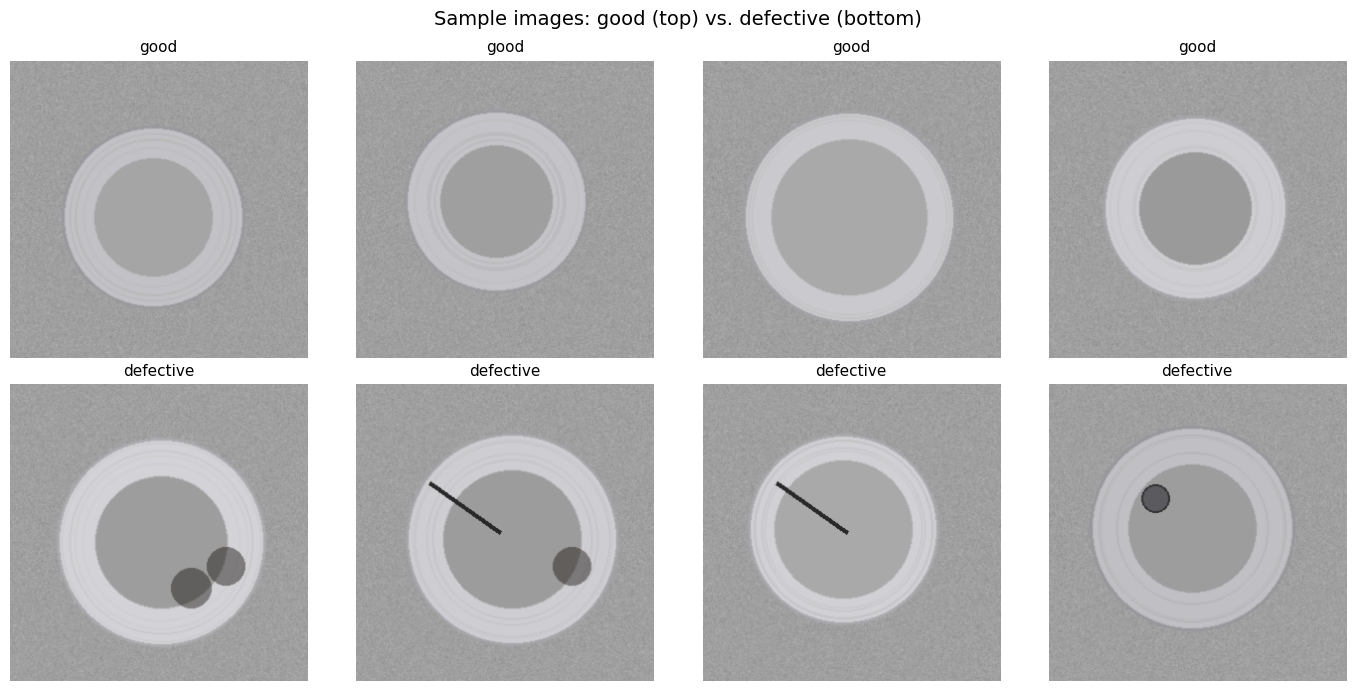

In [3]:
# Quick visual sanity check: a few examples from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
good_samples = sorted(os.listdir("dataset/train/good"))[:4]
bad_samples = sorted(os.listdir("dataset/train/defective"))[:4]

for i, fname in enumerate(good_samples):
    img = Image.open(f"dataset/train/good/{fname}")
    axes[0, i].imshow(img)
    axes[0, i].set_title("good", fontsize=11)
    axes[0, i].axis("off")

for i, fname in enumerate(bad_samples):
    img = Image.open(f"dataset/train/defective/{fname}")
    axes[1, i].imshow(img)
    axes[1, i].set_title("defective", fontsize=11)
    axes[1, i].axis("off")

plt.suptitle("Sample images: good (top) vs. defective (bottom)", fontsize=14)
plt.tight_layout()
plt.show()


### 1.2 Image Preprocessing: Resize to 224×224 + ResNet50-Compatible Normalization

ResNet50 was trained on ImageNet with images resized to **224×224×3** and normalized
using the channel-wise mean subtraction that Keras' `preprocess_input` for ResNet50
applies (BGR ordering, ImageNet channel means subtracted — *not* simple `/255` scaling).
Matching this exactly matters: if our input distribution doesn't match what the frozen
backbone was trained on, its learned filters will respond to the wrong intensity
ranges and feature extraction quality degrades.

We use `tensorflow.keras.applications.resnet50.preprocess_input` as the
`preprocessing_function` inside `ImageDataGenerator`, which handles the resize-to-224
target via `target_size` and the ResNet50-specific normalization automatically.


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# preprocess_input applies the exact mean-subtraction/channel-ordering ResNet50
# expects -- this replaces a naive `rescale=1./255` for transfer learning with
# ImageNet-pretrained backbones.
print("ResNet50 preprocess_input will be applied via ImageDataGenerator below.")


ResNet50 preprocess_input will be applied via ImageDataGenerator below.


### 1.3 Data Augmentation Strategy

Our synthetic dataset (and most real-world QC datasets) is small relative to what a
CNN trained from scratch would need. **Data augmentation** synthetically expands the
effective training set by applying realistic transformations that preserve the label
(a flipped or slightly rotated defective part is still defective), which:

- **Reduces overfitting** — the frozen backbone + lightweight head combination has
  far fewer trainable parameters than a from-scratch CNN, but the *head* can still
  memorize a small training set without augmentation.
- **Improves robustness** — parts on a real conveyor belt arrive at the camera in
  arbitrary rotations and positions, so the model should be invariant to these.

**Augmentation choices and rationale:**

| Augmentation | Range | Why |
|---|---|---|
| `rotation_range` | 25° | Parts on a conveyor are not perfectly aligned |
| `width_shift_range` / `height_shift_range` | 10% | Camera framing/centering varies slightly |
| `horizontal_flip` / `vertical_flip` | True | A defect's class doesn't depend on orientation — mirrored parts are equally valid |
| `zoom_range` | 15% | Accounts for minor variation in part-to-camera distance |
| `brightness_range` | 0.85–1.15 | Simulates inconsistent factory floor lighting |

We deliberately **avoid** aggressive augmentations like large shears or extreme color
jitter, since they could distort small defects (e.g. a hairline scratch) past the
point of being visually detectable, which would corrupt the label.


In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest",
)

# Test/validation data is NOT augmented -- we want to evaluate on realistic,
# un-distorted images that reflect what the model will see in production.
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["good", "defective"],  # explicit ordering: good=0, defective=1
    shuffle=True,
    seed=SEED,
)

test_generator = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["good", "defective"],
    shuffle=False,  # keep order fixed so predictions line up with labels for evaluation
)

print("\nClass index mapping:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Test samples:", test_generator.samples)


Found 600 images belonging to 2 classes.
Found 150 images belonging to 2 classes.

Class index mapping: {'good': 0, 'defective': 1}
Training samples: 600
Test samples: 150


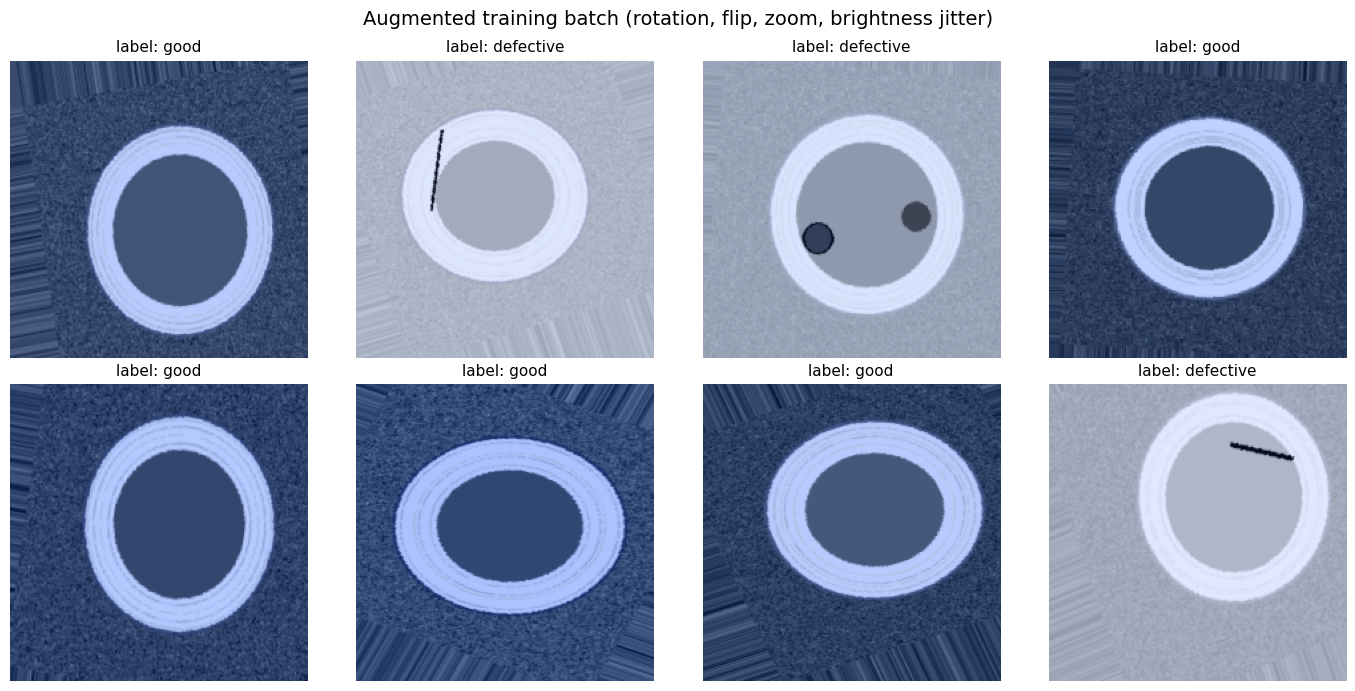

In [6]:
# Visualize a batch of augmented training images to confirm the pipeline behaves as expected
sample_batch_x, sample_batch_y = next(train_generator)

# Undo preprocess_input's normalization just for display purposes
def deprocess_for_display(img):
    img = img.copy()
    # reverse approximate ImageNet BGR mean-subtraction for visualization
    img = img[..., ::-1]  # BGR -> RGB
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(deprocess_for_display(sample_batch_x[i]))
    label = "defective" if sample_batch_y[i] == 1 else "good"
    ax.set_title(f"label: {label}", fontsize=11)
    ax.axis("off")
plt.suptitle("Augmented training batch (rotation, flip, zoom, brightness jitter)", fontsize=14)
plt.tight_layout()
plt.show()

# reset the generator so the demo batch above doesn't skip data during actual training
train_generator.reset()


## 2. Technical Phase — The "Brain Swap"

This is the core transfer-learning operation: we take a CNN that already knows how
to "see" — edges, textures, shapes, color gradients, object parts — from training on
1.28M ImageNet images across 1,000 categories, **strip off its final classification
layer** (which only knows how to predict ImageNet's 1,000 classes), and **bolt on a
new, small classification head** trained specifically to distinguish `good` vs.
`defective` parts.

> **Run this section in Google Colab (or any environment with internet access).**
> The next cell downloads ~90MB of pre-trained ImageNet weights from
> `storage.googleapis.com`. Everything from here through the end of the notebook
> depends on that download succeeding.

### 2.1 Import Pre-trained ResNet50 (feature extractor only)

`include_top=False` removes the original 1000-class ImageNet output layer and the
preceding `Flatten`/`Dense` block, leaving only the convolutional feature-extraction
backbone — exactly the part of the network we want to reuse.


In [7]:
base_model = ResNet50(
    weights="imagenet",      # load ImageNet-pretrained weights
    include_top=False,       # drop the original 1000-class classification head
    input_shape=(224, 224, 3),
)

print(f"Base model has {len(base_model.layers)} layers")
print(f"Output feature map shape: {base_model.output_shape}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base model has 175 layers
Output feature map shape: (None, 7, 7, 2048)


### 2.2 Freeze the Base Model

Setting `base_model.trainable = False` locks every weight in the ResNet50 backbone
so that **backpropagation does not update them** during initial training. We only
train the new head we're about to attach.

**Why freeze?**

1. **Preserve learned features.** ResNet50's early/mid layers encode generic visual
   primitives (edges, corners, textures, gradients) that transfer well to almost any
   vision task — including spotting scratches and dents. Unfreezing immediately would
   risk **catastrophic forgetting**: large gradient updates driven by our small,
   randomly-initialized head would propagate back and destroy these useful weights
   before the head has learned anything sensible.
2. **Fewer trainable parameters → less overfitting risk.** Our dataset is small
   relative to ImageNet. Training all 23.5M ResNet50 parameters on a few hundred
   images would overfit almost immediately. Training only the head's ~260K parameters
   is far more appropriate for the data volume available.
3. **Faster training.** Forward passes through the frozen backbone are still required,
   but no gradients are computed or weights updated for it, substantially reducing
   compute and training time, which matters when iterating on a factory floor pilot.

*(A follow-up "fine-tuning" stage — unfreezing the top few backbone blocks at a very
low learning rate — is a natural next step once the head has converged; see the
Limitations section.)*


In [8]:
base_model.trainable = False

# Confirm: the backbone should now show 0 trainable parameters
trainable_count = sum(tf.keras.backend.count_params(w) for w in base_model.trainable_weights)
total_count = base_model.count_params()
print(f"Base model trainable parameters: {trainable_count:,} / {total_count:,}")


Base model trainable parameters: 0 / 23,587,712


### 2.3 Construct the Custom Classification Head

`GlobalAveragePooling2D → Dense(ReLU) → Dense(Sigmoid)`

We add a `Dropout` layer between the dense layers as additional overfitting
protection, given our limited dataset size — this is a common, low-risk addition
that doesn't change the architecture's core design intent.


In [9]:
inputs = base_model.input
x = base_model.output                         # shape: (None, 7, 7, 2048)
x = GlobalAveragePooling2D()(x)                # shape: (None, 2048)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)                            # regularization given small dataset
outputs = Dense(1, activation="sigmoid")(x)    # binary defect probability

model = Model(inputs=inputs, outputs=outputs, name="resnet50_defect_classifier")
model.summary()


Model: "resnet50_defect_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 2.4 Compile and Train

We use:
- **Binary cross-entropy loss** — the standard loss function for binary classification
  with a sigmoid output.
- **Adam optimizer** at a modest learning rate (`1e-4`) — small enough not to
  destabilize the new head's early training, since this head's gradients are the
  only thing actually moving.
- **EarlyStopping** and **ReduceLROnPlateau** callbacks — standard guards against
  overfitting and stalled training, restoring the best-performing weights
  automatically.

We train for **15 epochs**, monitoring training/validation loss and accuracy.


In [10]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

EPOCHS = 15

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step - accuracy: 0.6283 - loss: 0.6523 - val_accuracy: 0.9933 - val_loss: 0.3012 - learning_rate: 1.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.8800 - loss: 0.3442 - val_accuracy: 1.0000 - val_loss: 0.1741 - learning_rate: 1.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9350 - loss: 0.2438 - val_accuracy: 1.0000 - val_loss: 0.1099 - learning_rate: 1.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9600 - loss: 0.1653 - val_accuracy: 1.0000 - val_loss: 0.0804 - learning_rate: 1.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 0.9683 - loss: 0.1388 - val_accuracy: 1.0000 - val_loss: 0.0696 - learning_rate: 1.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9650 - loss: 0.1264 - val_accuracy: 1.0000 - val_loss: 0.0538 - learning_rate: 1.0000e-04
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.9833 - loss:

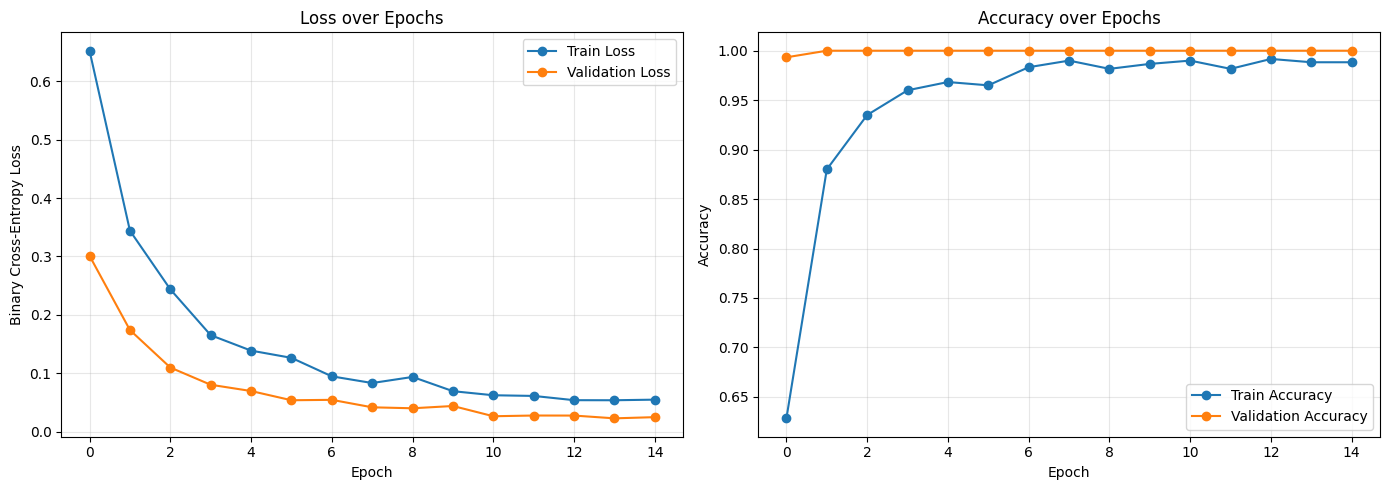

In [11]:
# Plot training/validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss", marker="o")
axes[0].plot(history.history["val_loss"], label="Validation Loss", marker="o")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="Train Accuracy", marker="o")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()


**Reading the curves:** If training accuracy climbs well above validation accuracy
(or validation loss starts climbing while training loss keeps falling), that's the
classic overfitting signature — at that point, consider stronger augmentation, more
dropout, or earlier stopping. If both curves plateau together at a high accuracy,
the frozen-backbone-plus-head setup has converged appropriately for this dataset size.


## 3. Model Evaluation — Classification Report

Accuracy alone can be misleading for a defect-detection task, especially if classes
are imbalanced (in a real factory, defective parts are usually much rarer than good
ones). **Precision** and **Recall** matter more here:

- **Recall (defective class)** — of all the *actually defective* parts, what fraction
  did the model catch? Low recall means **defective parts slip through to customers**
  — usually the costlier failure mode in QC.
- **Precision (defective class)** — of all parts the model *flagged* as defective,
  what fraction really were? Low precision means **good parts get wrongly rejected**,
  wasting good inventory and slowing the line.

In most manufacturing QC contexts, missing a real defect (false negative) is more
expensive than a false alarm (false positive), so recall on the `defective` class is
often the metric to optimize first, even at some cost to precision.


In [12]:
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=["good", "defective"]))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (rows=true, cols=predicted):")
print("              pred_good  pred_defective")
print(f"true_good        {cm[0][0]:>5}        {cm[0][1]:>5}")
print(f"true_defective   {cm[1][0]:>5}        {cm[1][1]:>5}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step
              precision    recall  f1-score   support

        good       1.00      1.00      1.00        75
   defective       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

Confusion Matrix (rows=true, cols=predicted):
              pred_good  pred_defective
true_good           75            0
true_defective       0           75


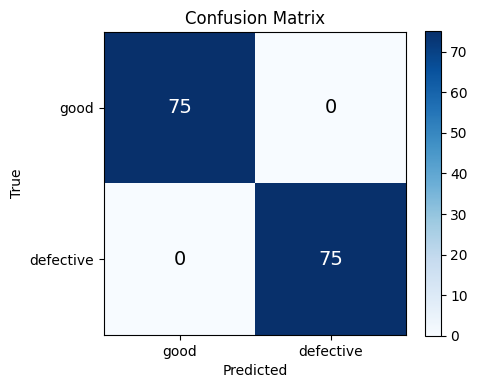

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["good", "defective"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["good", "defective"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()


## 4. Action Phase — From Prediction to Factory Automation

A model sitting in a notebook does nothing for a factory. The **Action** phase of DTA
is about converting a probability score into a deterministic, auditable decision a
**robotic arm / PLC (Programmable Logic Controller)** can execute on the line in
real time.

### 4.1 Inference on a New, Unseen Image


/tmp/ipykernel_2555/1478313526.py:6: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="L").convert("RGB")


Defect probability score: 0.9990  (99.9%)


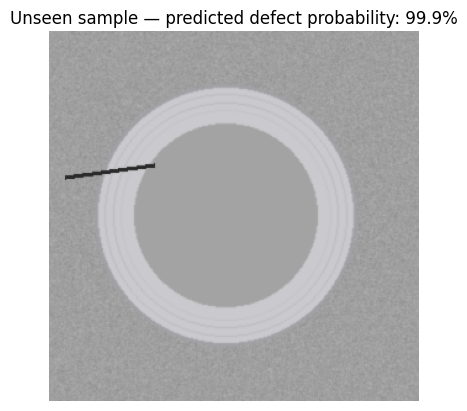

In [14]:
def predict_defect_probability(img_path, model, img_size=(224, 224)):
    # Loads a single image, preprocesses it identically to training, and
    # returns the model's defect probability score in [0, 1].
    img = Image.open(img_path).convert("RGB").resize(img_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)              # same normalization used in training
    arr = np.expand_dims(arr, axis=0)         # add batch dimension
    prob = model.predict(arr, verbose=0)[0][0]
    return float(prob)


# Generate a fresh, never-before-seen image as a stand-in for a live camera frame
unseen_img = draw_good_part(seed=99999)
unseen_img = add_defect(unseen_img, "scratch", seed=99999)
unseen_img.save("unseen_sample.png")

defect_prob = predict_defect_probability("unseen_sample.png", model)
print(f"Defect probability score: {defect_prob:.4f}  ({defect_prob*100:.1f}%)")

plt.imshow(unseen_img)
plt.title(f"Unseen sample — predicted defect probability: {defect_prob*100:.1f}%")
plt.axis("off")
plt.show()


### 4.2 Automated Decision Logic

We translate the probability score into a discrete factory action using a
**threshold-based decision policy**. The brief specifies the high-confidence reject
threshold at **≥ 85%**; we also define a lower-confidence "human review" band rather
than a single hard cutoff, since collapsing everything below 85% straight to "pass"
would let borderline/ambiguous parts through with no oversight.


In [15]:
def factory_decision(defect_probability: float) -> dict:
    # Maps a defect probability score to a concrete automation action.
    #
    # Decision bands:
    #   >= 0.85       -> REJECT : high-confidence defect. Robotic arm diverts
    #                              the part to the reject bin. No human needed.
    #   0.50 - 0.849  -> HOLD   : ambiguous. Robotic arm routes the part to a
    #                              manual inspection lane instead of the main line.
    #   < 0.50        -> PASS   : high-confidence good part. Robotic arm allows
    #                              the part to continue down the main conveyor.
    if defect_probability >= 0.85:
        action = "REJECT"
        instruction = "Robotic arm: divert part to REJECT bin. Log event with image + score."
    elif defect_probability >= 0.50:
        action = "HOLD_FOR_REVIEW"
        instruction = "Robotic arm: route part to MANUAL INSPECTION lane. Flag for human QA."
    else:
        action = "PASS"
        instruction = "Robotic arm: no action — allow part to continue on main conveyor."

    return {
        "defect_probability": round(defect_probability, 4),
        "action": action,
        "robotic_arm_instruction": instruction,
    }


decision = factory_decision(defect_prob)
for k, v in decision.items():
    print(f"{k}: {v}")


defect_probability: 0.999
action: REJECT
robotic_arm_instruction: Robotic arm: divert part to REJECT bin. Log event with image + score.


In [16]:
# Demonstrate the decision logic across the full test set
test_generator.reset()
all_probs = model.predict(test_generator, verbose=0).flatten()

decisions = [factory_decision(p)["action"] for p in all_probs]
from collections import Counter
print("Decision distribution across test set:")
for action, count in Counter(decisions).items():
    print(f"  {action}: {count} parts ({count/len(decisions)*100:.1f}%)")


Decision distribution across test set:
  PASS: 75 parts (50.0%)
  REJECT: 74 parts (49.3%)
  HOLD_FOR_REVIEW: 1 parts (0.7%)


### 4.3 Why GlobalAveragePooling2D Instead of Flatten?

This is one of the most consequential architectural choices in this design, and is
worth justifying explicitly:

| Aspect | `Flatten()` | `GlobalAveragePooling2D()` |
|---|---|---|
| **Output size** | Flattens the full `7×7×2048` feature map into a `100,352`-length vector | Averages each of the 2048 channels into a single value → `2048`-length vector |
| **Parameters in next Dense layer** | `100,352 × 128 ≈ 12.8M` params just for the first dense layer | `2048 × 128 ≈ 262K` params — roughly **49× fewer** |
| **Overfitting risk** | High — a huge dense layer on a small dataset memorizes easily | Much lower — far fewer weights to overfit with |
| **Spatial sensitivity** | Preserves exact spatial position of every feature in the flattened vector — sensitive to *where* in the 7×7 grid a feature was detected | Discards exact position, retaining only "how strongly was this feature present, on average, anywhere in the image" |
| **Generalization to different input sizes/positions** | Brittle — a defect 1 pixel to the left changes which flattened index is activated | Robust — a defect anywhere in the frame contributes similarly to the same averaged channel value |

**Practically, for this task:** a scratch's exact pixel coordinates don't matter — a
scratch in the top-left of the frame is just as defective as one in the
bottom-right. `GlobalAveragePooling2D` encodes *"is this feature present somewhere in
the image"* rather than *"is this feature present at this exact location"*, which is
precisely the right inductive bias for whole-part defect classification (as opposed
to, say, defect *localization*, where preserving spatial structure — and using
something like a fully convolutional or detection head — would matter more).

Combined with the **parameter reduction** described above, `GlobalAveragePooling2D`
is the standard choice for transfer-learning classification heads on top of frozen
CNN backbones, and is why it appears in this design rather than `Flatten()`.


## 5. Limitations, Threshold Tuning, and Next Steps for Real Deployment

### Limitations of this notebook as-is

1. **Synthetic data.** The dataset is procedurally generated, not real factory
   imagery. Real defects (oxidation, weld spatter, dimensional warping, multi-material
   surfaces, varying lighting/glare from factory lighting rigs) are visually far more
   diverse than the four synthetic defect types used here. Performance on this
   synthetic set should be treated as a **pipeline validation**, not a production
   performance estimate.
2. **Single defect category.** This model only distinguishes `good` vs. `defective`
   in aggregate. It does not classify defect *type* (scratch vs. dent vs. crack),
   which a real deployment likely needs for root-cause analysis on the production line.
3. **No class imbalance handling.** Our synthetic data is balanced 50/50. Real
   factory defect rates are often well under 5%, which would require techniques like
   class weighting, focal loss, or oversampling the minority (defective) class during
   training — without these, a model trained on a heavily imbalanced real dataset can
   collapse to always predicting "good."
4. **Frozen backbone only.** We never unfroze and fine-tuned any ResNet50 layers.
   Fine-tuning the top 1-2 residual blocks at a very low learning rate
   (after the head has converged) typically yields a meaningful accuracy boost by
   letting the backbone adapt its highest-level features specifically to the texture
   patterns of metal defects, rather than relying solely on generic ImageNet features.

### Threshold tuning considerations

The 0.85 reject threshold and 0.50 hold threshold used above are **business policy
choices**, not properties learned by the model — they should be tuned using the
**precision-recall tradeoff** on a validation set sized and sampled to match real
production defect rates, guided by the actual cost asymmetry between:

- **False negative cost** (a defective part ships to a customer — recalls, brand
  damage, possibly safety liability), versus
- **False positive cost** (a good part gets scrapped or sent to manual review —
  wasted material/labor, slower line throughput).

In most manufacturing contexts the false-negative cost dominates, which argues for
a **lower** reject threshold than 0.85 in practice (catching more true defects at the
cost of some false alarms) — but this notebook implements the brief's specified
threshold as a starting point for that tuning conversation, not a final answer.

### Next steps for real-world industrial deployment

1. **Collect and label a real defect-image dataset** from the actual production line
   and camera setup, ideally across different lighting conditions, shifts, and part
   orientations.
2. **Calibrate the threshold(s)** against a precision-recall curve computed on this
   real validation data, in collaboration with the QC team's actual cost tolerances.
3. **Fine-tune the backbone** (selectively unfreeze top ResNet50 blocks) once enough
   real labeled data is available to do so without overfitting.
4. **Add defect-type sub-classification** if root-cause tracking is valuable to the
   plant (multi-class or multi-label head instead of binary).
5. **Latency/throughput testing on target hardware** (e.g. an edge inference device
   mounted at the camera, not a cloud GPU) to confirm the model meets the conveyor
   belt's required inspection cycle time.
6. **Shadow-mode deployment** — run the model alongside existing human/automated QC
   for a trial period, logging disagreements, before giving it actual reject authority
   over the robotic arm.
7. **Monitoring and drift detection** — track the live defect-probability score
   distribution over time in production; a shift can indicate camera drift, lighting
   changes, or a genuine change in upstream manufacturing quality.


## 6. Using a Real Dataset Instead

To point this notebook at a real dataset (for example, a casting-defect dataset),
arrange your images as:

```
dataset/
├── train/
│   ├── good/
│   │   ├── img001.jpg
│   │   └── ...
│   └── defective/
│       ├── img001.jpg
│       └── ...
└── test/
    ├── good/
    └── defective/
```

and simply **skip the `generate_dataset()` call in Section 1.1** — every cell from
Section 1.2 onward (`ImageDataGenerator`, model construction, training, evaluation,
inference, and decision logic) works unmodified against any dataset following this
folder structure.
